<a href="https://colab.research.google.com/github/takuya0724/sticker-pro/blob/main/%E3%82%B9%E3%82%BF%E3%83%B3%E3%83%97%E8%81%B7%E4%BA%BA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# StickerPro Ultimate v6.0
# Cell① 初期設定
# ============================================================

from google.colab import files
from PIL import Image
from PIL import ImageOps
import numpy as np
import os
import shutil
import zipfile

# ===== 設定 =====

# 16分割（将来48にも変更可能）
ROWS = 4
COLS = 4

# LINEスタンプサイズ
OUTPUT_WIDTH = 370
OUTPUT_HEIGHT = 320

# 作業フォルダ
WORK_FOLDER = "StickerPro"
CUT_FOLDER = os.path.join(WORK_FOLDER, "cut")
LINE_FOLDER = os.path.join(WORK_FOLDER, "line")

# 作り直し
if os.path.exists(WORK_FOLDER):
    shutil.rmtree(WORK_FOLDER)

os.makedirs(CUT_FOLDER)
os.makedirs(LINE_FOLDER)

print("======================================")
print(" StickerPro Ultimate v6.0")
print(" 初期化完了")
print("======================================")

 StickerPro Ultimate v6.0
 初期化完了


スタンプシート画像を選択してください


Saving file_0000000077d08209b4de00499d076029.png to file_0000000077d08209b4de00499d076029.png
読み込み完了：file_0000000077d08209b4de00499d076029.png
画像サイズ：(1254, 1254)


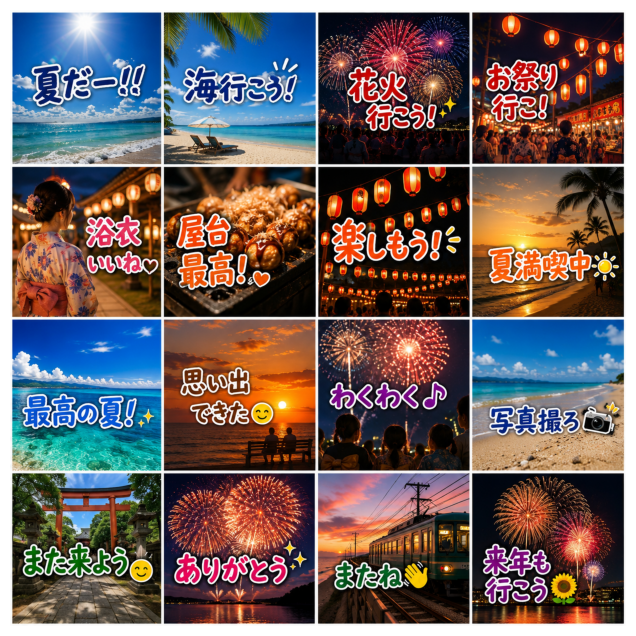

In [5]:
# ============================================================
# StickerPro Ultimate v6.0
# Cell② 画像アップロード
# ============================================================

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

print("スタンプシート画像を選択してください")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGBA")

print(f"読み込み完了：{filename}")
print(f"画像サイズ：{img.size}")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [3]:
# ============================================================
# StickerPro Ultimate v6.0
# Cell③ 16分割・背景透過・トリミング
# ============================================================

from PIL import Image
import numpy as np
import os

# img は Cell②で読み込んだ画像
width, height = img.size

piece_w = width // COLS
piece_h = height // ROWS

print("16分割開始...")

count = 1

for r in range(ROWS):
    for c in range(COLS):

        left = c * piece_w
        upper = r * piece_h
        right = left + piece_w
        lower = upper + piece_h

        piece = img.crop((left, upper, right, lower)).convert("RGBA")

        data = np.array(piece)

        # 白背景を透過
        r_ch = data[:, :, 0]
        g_ch = data[:, :, 1]
        b_ch = data[:, :, 2]

        mask = (
            (r_ch > 245) &
            (g_ch > 245) &
            (b_ch > 245)
        )

        data[mask, 3] = 0

        piece = Image.fromarray(data)

        # 透明部分を除いてトリミング
        bbox = piece.getbbox()

        if bbox:
            piece = piece.crop(bbox)

        save_path = os.path.join(
            CUT_FOLDER,
            f"sticker_{count:02}.png"
        )

        piece.save(save_path)

        print(f"保存：sticker_{count:02}.png")

        count += 1

print()
print("✅ 16枚の切り出し完了！")

16分割開始...
保存：sticker_01.png
保存：sticker_02.png
保存：sticker_03.png
保存：sticker_04.png
保存：sticker_05.png
保存：sticker_06.png
保存：sticker_07.png
保存：sticker_08.png
保存：sticker_09.png
保存：sticker_10.png
保存：sticker_11.png
保存：sticker_12.png
保存：sticker_13.png
保存：sticker_14.png
保存：sticker_15.png
保存：sticker_16.png

✅ 16枚の切り出し完了！


In [4]:
# ============================================================
# StickerPro Ultimate v6.0
# Cell④ LINEスタンプサイズへ変換
# ============================================================

from PIL import Image
import os

print("LINEスタンプ用画像を作成中...")

for i in range(1, ROWS * COLS + 1):

    src = os.path.join(CUT_FOLDER, f"sticker_{i:02}.png")

    if not os.path.exists(src):
        continue

    sticker = Image.open(src).convert("RGBA")

    # LINEサイズの透明キャンバス
    canvas = Image.new(
        "RGBA",
        (OUTPUT_WIDTH, OUTPUT_HEIGHT),
        (255, 255, 255, 0)
    )

    # 縦横比を維持して90%以内に収める
    ratio = min(
        (OUTPUT_WIDTH * 0.9) / sticker.width,
        (OUTPUT_HEIGHT * 0.9) / sticker.height
    )

    new_size = (
        max(1, int(sticker.width * ratio)),
        max(1, int(sticker.height * ratio))
    )

    sticker = sticker.resize(new_size, Image.Resampling.LANCZOS)

    x = (OUTPUT_WIDTH -

SyntaxError: incomplete input (3511258052.py, line 40)

In [ ]:
# ============================================================
# StickerPro Ultimate v6.0
# Cell⑤ ZIP作成・ダウンロード
# ============================================================

from google.colab import files
import os
import zipfile

zip_name = "StickerPro_LINE_Stamps.zip"

# 古いZIPがあれば削除
if os.path.exists(zip_name):
    os.remove(zip_name)

print("ZIPファイルを作成中...")

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:

    for i in range(1, ROWS * COLS + 1):

        file_path = os.path.join(
            LINE_FOLDER,
            f"line_{i:02}.png"
        )

        if os.path.exists(file_path):
            zipf.write(
                file_path,
                arcname=f"line_{i:02}.png"
            )

print("✅ ZIP作成完了！")
print("ダウンロードを開始します。")

files.download(zip_name)